# variable7: 지하철 호선 수 계산


In [1]:
!pip install requests pandas -q

In [2]:
# 라이브러리 임포트

import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
# 설정값

KAKAO_API_KEY = "535c6e3c45e29358987222e3a1e4af76"
WALK_RADIUS_M = 3000
NEW_COL       = "지하철호선개수"
API_SLEEP     = 0.1

INPUT_PATH = "new_city.csv" # 변수 추출하고자 하는 csv 파일명을 입력
ENCODING   = "utf-8-sig"

In [4]:
# 기존 컬럼 초기화

df = pd.read_csv("new_city.csv", encoding='utf-8-sig', dtype=str) # 변수 추출하고자 하는 csv 파일명을 입력
df = df.drop(columns=['지하철호선개수'], errors='ignore')
df.to_csv("new_city.csv", index=False, encoding='utf-8-sig') # 변수 추출하고자 하는 csv 파일명을 입력
print("기존 '지하철호선개수' 컬럼 삭제 완료 → 재계산 시작")

기존 '지하철호선개수' 컬럼 삭제 완료 → 재계산 시작


In [5]:
# API 연결 확인 

url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
params = {"query": "인천광역시 서구 청라동"}

resp = requests.get(url, headers=headers, params=params)
print(f"상태 코드: {resp.status_code}")
print(resp.json())

상태 코드: 200
{'documents': [{'address': {'address_name': '인천 서구 청라동', 'b_code': '2826012200', 'h_code': '', 'main_address_no': '', 'mountain_yn': 'N', 'region_1depth_name': '인천', 'region_2depth_name': '서구', 'region_3depth_h_name': '', 'region_3depth_name': '청라동', 'sub_address_no': '', 'x': '126.630970210614', 'y': '37.5360210477791'}, 'address_name': '인천 서구 청라동', 'address_type': 'REGION', 'road_address': None, 'x': '126.630970210614', 'y': '37.5360210477791'}, {'address': {'address_name': '인천 서구 청라1동', 'b_code': '', 'h_code': '2826053600', 'main_address_no': '', 'mountain_yn': 'N', 'region_1depth_name': '인천', 'region_2depth_name': '서구', 'region_3depth_h_name': '청라1동', 'region_3depth_name': '', 'sub_address_no': '', 'x': '126.653691529733', 'y': '37.5326264337022'}, 'address_name': '인천 서구 청라1동', 'address_type': 'REGION', 'road_address': None, 'x': '126.653691529733', 'y': '37.5326264337022'}, {'address': {'address_name': '인천 서구 청라2동', 'b_code': '', 'h_code': '2826053700', 'main_address_no

In [6]:
# 유틸리티 함수 (API 관련 - 핵심기능)

def address_to_coords(address, api_key):
    url     = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params  = {"query": address, "analyze_type": "similar"}
    try:
        resp = requests.get(url, headers=headers, params=params, timeout=5)
        resp.raise_for_status()
        docs = resp.json().get("documents", [])
        if docs:
            return float(docs[0]["y"]), float(docs[0]["x"])
    except Exception as e:
        print(f"  [좌표 변환 오류] {address}: {e}")
    return None


def search_keyword(lat, lon, keyword, radius, api_key):
    url     = "https://dapi.kakao.com/v2/local/search/keyword.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    results = []
    for page in range(1, 4):
        params = {
            "query" : keyword, "x": lon, "y": lat,
            "radius": radius,  "size": 15, "page": page, "sort": "distance"
        }
        try:
            resp = requests.get(url, headers=headers, params=params, timeout=5)
            resp.raise_for_status()
            data = resp.json()
            results.extend(data.get("documents", []))
            if data["meta"].get("is_end", True):
                break
            time.sleep(API_SLEEP)
        except Exception as e:
            print(f"  [키워드 검색 오류] {keyword}: {e}")
            break
    return results


In [7]:
# 호선 추출 함수

# 긴 이름(특수 노선)을 앞에 배치해 매칭 오류 방지
SUBWAY_LINES = [
    "인천1호선", "인천2호선",
    "수인분당선", "신분당선", "경의중앙선", "공항철도",
    "경춘선", "GTX-A", "GTX-B", "GTX-C",
    "서해선", "신림선", "우이신설선", "김포골드라인",
    "1호선", "2호선", "3호선", "4호선", "5호선",
    "6호선", "7호선", "8호선", "9호선",
]


def extract_line(place_name):
    for line in SUBWAY_LINES:
        if line in place_name:
            return line
    return None


def calc_subway_lines(lat, lon, api_key, radius=WALK_RADIUS_M):
    places      = search_keyword(lat, lon, "지하철역", radius, api_key)
    lines_found = set()
    for place in places:
        line = extract_line(place.get("place_name", ""))
        if line:
            lines_found.add(line)
    return len(lines_found)


In [8]:
# 좌표 변환 폴백 함수

# 아래 네 곳은 카카오 API로 좌표변환이 어려워 직접 좌표값을 넣음.
MANUAL_COORDS = {
    "청라한양수자인":                (37.5269691, 126.621144),
    "청라디이스트":                  (37.5274766, 126.6234658),
    "청라모아미래도":                (37.5385249, 126.6206428),
    "청라국제업무단지센텀대광로제비앙": (37.5380479, 126.6230073),
}


def get_coords_with_fallback(row, api_key):
    sigungu = str(row['시군구']).strip()
    dorname = str(row['도로명']).strip()
    aptname = str(row['단지명']).strip()

    if aptname in MANUAL_COORDS:
        return MANUAL_COORDS[aptname], '수동입력'

    coords = address_to_coords(f"{sigungu} {dorname}", api_key)
    if coords:
        return coords, '도로명'

    coords = address_to_coords(f"{sigungu} {aptname}", api_key)
    if coords:
        return coords, '단지명'

    clean_name = aptname.split('(')[0].strip()
    coords = address_to_coords(f"{sigungu} {clean_name}", api_key)
    if coords:
        return coords, '단지명(괄호제거)'

    return None, None


In [9]:
# 메인 처리 함수

def add_subway_lines(input_path, api_key, encoding=ENCODING):
    df = pd.read_csv(input_path, encoding=encoding)
    print(f"파일: {input_path}")
    print(f"전체 행: {len(df)}행 / 컬럼: {list(df.columns)}")

    unique_complexes = df[['단지명', '시군구', '도로명']].drop_duplicates(subset='단지명').reset_index(drop=True)
    print(f"\n고유 단지 수: {len(unique_complexes)}개")

    cache = {}

    for i, row in unique_complexes.iterrows():
        apt_name = row['단지명']
        print(f"  [{i+1}/{len(unique_complexes)}] {apt_name}")

        coords, method = get_coords_with_fallback(row, api_key)
        time.sleep(API_SLEEP)

        if coords is None:
            print(f"    → 3차 시도 모두 실패")
            cache[apt_name] = np.nan
            continue

        lat, lon = coords
        places    = search_keyword(lat, lon, "지하철역", WALK_RADIUS_M, api_key)
        raw_names = [p.get("place_name", "") for p in places]
        print(f"    → [{method}] 검색된 역 ({len(raw_names)}개): {raw_names}")

        lines_found = set()
        for name in raw_names:
            line = extract_line(name)
            if line:
                lines_found.add(line)

        print(f"    → 매칭된 호선: {lines_found if lines_found else '없음'} → {len(lines_found)}개")
        cache[apt_name] = len(lines_found)

    df[NEW_COL] = df['단지명'].map(cache)
    df.to_csv(input_path, index=False, encoding=encoding)
    print(f"\n저장 완료: {input_path}")
    print(f"추가된 컬럼: '{NEW_COL}'")
    print(f"\n===== {NEW_COL} 요약 통계 =====")
    print(df[NEW_COL].describe())
    print("\n값 분포:")
    print(df[NEW_COL].value_counts().sort_index())
    return df


In [10]:
# 분포 시각화

def plot_distribution(df):
    if NEW_COL not in df.columns:
        print("지하철호선개수 컬럼이 없습니다.")
        return

    counts = df[NEW_COL].dropna().value_counts().sort_index()
    plt.plot(counts.index, counts.values, 'o-')
    plt.xlabel("호선 수")
    plt.ylabel("거래 건수")
    plt.title("변수7: 대중교통 3000m 내 지하철 호선 수 분포")
    plt.show()


파일: new_city.csv
전체 행: 90761행 / 컬럼: ['도시명', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '동', '층', '건축년도', '도로명', '자족용지비율', '가장 가까운 지하철역', '가장 가까운 지하철역까지의 거리', '가장 가까운 고속도로 IC', '가장 가까운 IC와의 거리', '계약연도', '발표후경과년수', 'CPI', '서울도심거리', '단지별_세대수', '도시별_세대수', '기차역까지의거리', '기차역이름']

고유 단지 수: 208개
  [1/208] 청라웰카운티1차
    → [도로명] 검색된 역 (4개): ['서구청역 인천2호선', '가정역 인천2호선', '아시아드경기장역 인천2호선', '가정중앙시장역 인천2호선']
    → 매칭된 호선: {'인천2호선'} → 1개
  [2/208] 힐데스하임
    → [도로명] 검색된 역 (3개): ['가정역 인천2호선', '가정중앙시장역 인천2호선', '서구청역 인천2호선']
    → 매칭된 호선: {'인천2호선'} → 1개
  [3/208] 호반베르디움앤영무예다음
    → [도로명] 검색된 역 (4개): ['서구청역 인천2호선', '가정역 인천2호선', '아시아드경기장역 인천2호선', '가정중앙시장역 인천2호선']
    → 매칭된 호선: {'인천2호선'} → 1개
  [4/208] 호반베르디움(116-6)
    → [도로명] 검색된 역 (3개): ['서구청역 인천2호선', '가정역 인천2호선', '아시아드경기장역 인천2호선']
    → 매칭된 호선: {'인천2호선'} → 1개
  [5/208] 청라하우스토리커낼뷰
    → [도로명] 검색된 역 (2개): ['청라국제도시역 공항철도', '청라국제도시역 공항철도 대합실']
    → 매칭된 호선: {'공항철도'} → 1개
  [6/208] 서해그랑블
    → [도로명] 검색된 역 (4개): ['가정역 인천2호선', '서구청역 인천2호

c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Dej

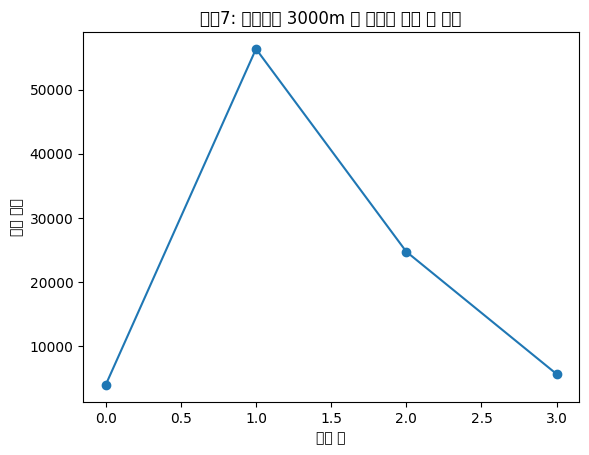

In [11]:
# 실행

result_df = add_subway_lines(
    input_path = INPUT_PATH,
    api_key    = KAKAO_API_KEY,
    encoding   = ENCODING
)
plot_distribution(result_df)
